In [1]:
print("hello world")

hello world


     AI NETWORK SECURITY ANALYZER SYSTEM          

--- 1. Loading NSL-KDD Dataset ---
Loaded dataset successfully: 125973 rows x 43 columns.

--- 2. Exploratory Data Analysis (EDA) ---

[A] First 10 Records:
   duration protocol_type     service flag  src_bytes  dst_bytes  land  \
0         0           tcp    ftp_data   SF        491          0     0   
1         0           udp       other   SF        146          0     0   
2         0           tcp     private   S0          0          0     0   
3         0           tcp        http   SF        232       8153     0   
4         0           tcp        http   SF        199        420     0   
5         0           tcp     private  REJ          0          0     0   
6         0           tcp     private   S0          0          0     0   
7         0           tcp     private   S0          0          0     0   
8         0           tcp  remote_job   S0          0          0     0   
9         0           tcp     private   S0         

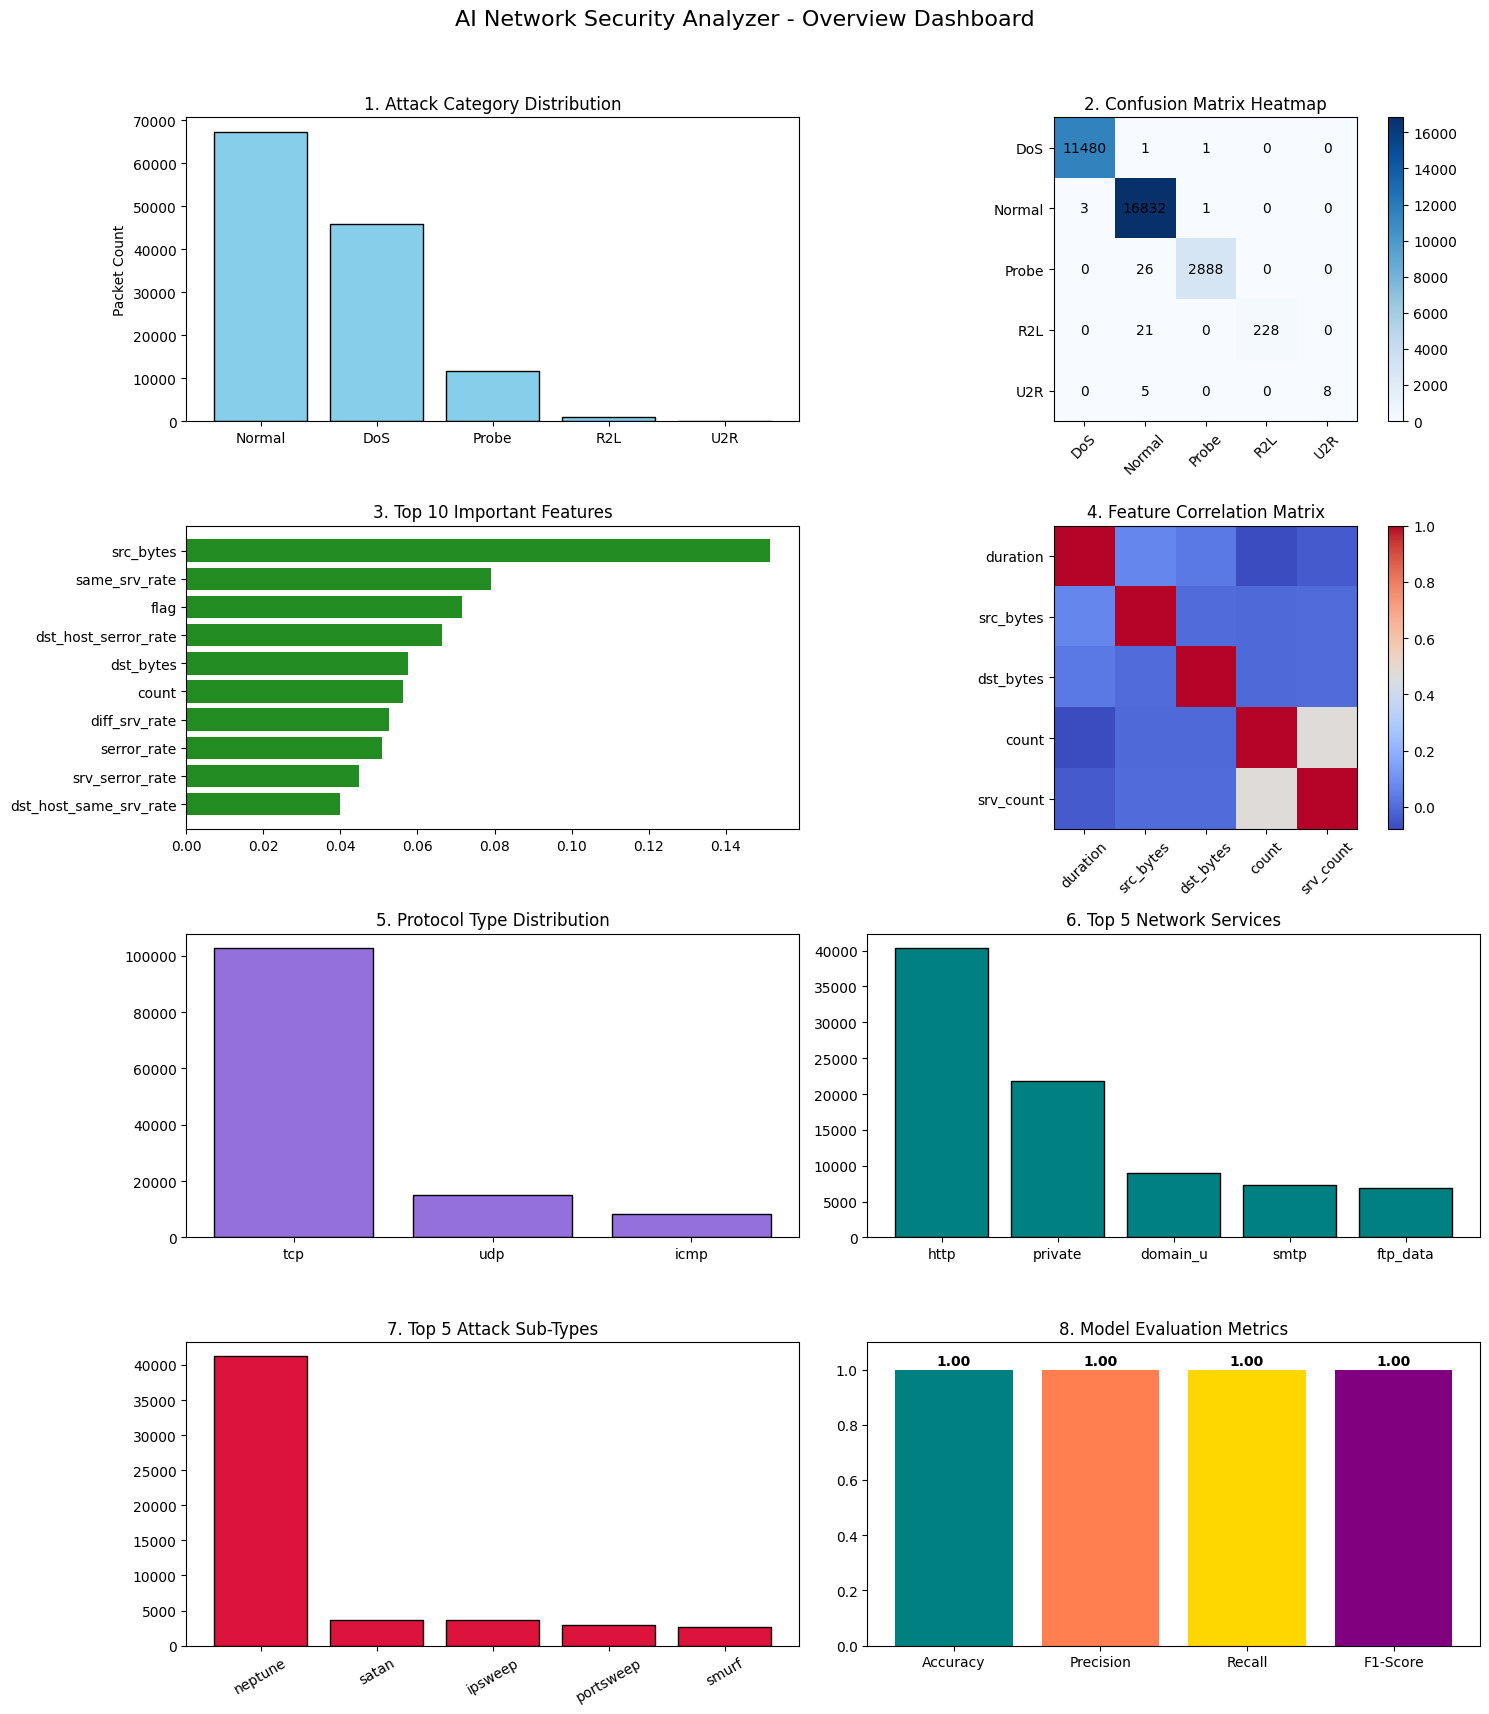

--- 7. Real-Time Terminal AI Security Analyzer ---

================ AI ANALYSIS RESULT ================
Predicted Class    : NORMAL
Confidence Score   : 96.35%
Risk Level         : LOW
Description        : Standard legitimate network traffic behavior.
Security Action    : No action required. Continue routine operational monitoring.

Log appended to 'prediction_history.csv'.


C:\Users\kapoo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\kapoo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



--- 8. AI Network Security Final Summary Report ---
Total Packets Analyzed : 1
Total Attacks Detected : 0
 - Normal Traffic Count: 1
 - DoS Attacks Count   : 0
 - Probe Attacks Count : 0
 - R2L Attacks Count   : 0
 - U2R Attacks Count   : 0
Detection Accuracy     : 99.82%
System Security Status : [OPTIMAL]

AI Network Security Analyzer shutting down safely. Goodbye!


In [2]:
import os
import urllib.request
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Global Constants & Paths
DATASET_FILE = "KDDTrain+.txt"
DATASET_URL = (
    "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
)
PREDICTION_HISTORY_FILE = "prediction_history.csv"

# NSL-KDD Dataset Column Specifications
COLUMN_NAMES = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack_type",
    "difficulty_level",
]

# Mapping 38 specific attack sub-types to 5 Core Security Categories
ATTACK_MAPPING = {
    "normal": "Normal",
    # DoS (Denial of Service)
    "neptune": "DoS",
    "back": "DoS",
    "land": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "mailbomb": "DoS",
    "apache2": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",
    # Probe (Surveillance / Reconnaissance)
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    # R2L (Remote to Local)
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "snmpgetattack": "R2L",
    "snmpguess": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "httptunnel": "R2L",
    # U2R (User to Root)
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R",
    "ps": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
}

# Explicit Threat Intelligence Dictionary
THREAT_INTEL = {
    "Normal": {
        "risk": "Low",
        "description": "Standard legitimate network traffic behavior.",
        "action": "No action required. Continue routine operational monitoring.",
    },
    "DoS": {
        "risk": "High",
        "description": "Denial of Service attack attempting to overwhelm system resources.",
        "action": "Enable rate limiting, trigger IP blocklisting, and scale firewall filtering.",
    },
    "Probe": {
        "risk": "Medium",
        "description": "Surveillance or port scanning activity gathering network architecture intelligence.",
        "action": "Audit active open ports, restrict ICMP response packets, and inspect stealth scans.",
    },
    "R2L": {
        "risk": "High",
        "description": "Remote-to-Local compromise attempting unauthorized access from an external machine.",
        "action": "Enforce multi-factor authentication (MFA), update SSH configs, and review credentials.",
    },
    "U2R": {
        "risk": "Critical",
        "description": "User-to-Root privilege escalation exploit attempting full administrative takeover.",
        "action": "Isolate host system immediately, revoke session keys, and run kernel exploit audit.",
    },
}

CATEGORICAL_COLS = ["protocol_type", "service", "flag"]


def create_synthetic_dataset(filepath, num_samples=3000):
    """Fallback generator to construct a structured NSL-KDD formatted dataset if network fails."""
    print("Generating local fallback dataset...")
    np.random.seed(42)
    protocols = ["tcp", "udp", "icmp"]
    services = ["http", "private", "domain_u", "smtp", "ftp_data"]
    flags = ["SF", "S0", "REJ", "RSTR"]
    attack_keys = list(ATTACK_MAPPING.keys())

    data = []
    for _ in range(num_samples):
        attack = np.random.choice(
            attack_keys,
            p=[0.5] + [0.5 / (len(attack_keys) - 1)] * (len(attack_keys) - 1),
        )
        row = [
            np.random.randint(0, 500),  # duration
            np.random.choice(protocols),  # protocol_type
            np.random.choice(services),  # service
            np.random.choice(flags),  # flag
            np.random.randint(0, 10000),  # src_bytes
            np.random.randint(0, 10000),  # dst_bytes
            0,
            0,
            0,
            np.random.randint(0, 3),
            0,  # land..num_failed
            np.random.randint(0, 2),
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,
            0,  # logged_in..guest
            np.random.randint(1, 100),
            np.random.randint(1, 100),  # count, srv_count
            np.random.uniform(0.0, 1.0),
            np.random.uniform(0.0, 1.0),  # serror_rate..
            0.0,
            0.0,
            np.random.uniform(0.0, 1.0),
            np.random.uniform(0.0, 1.0),  # same_srv..
            0.0,
            np.random.randint(1, 255),
            np.random.randint(1, 255),  # dst_host..
            np.random.uniform(0.0, 1.0),
            np.random.uniform(0.0, 1.0),
            np.random.uniform(0.0, 1.0),
            0.0,
            0.0,
            0.0,
            0.0,
            0.0,
            attack,
            21,
        ]
        data.append(row)

    df = pd.DataFrame(data, columns=COLUMN_NAMES)
    df.to_csv(filepath, index=False, header=False)


def load_dataset():
    """Downloads NSL-KDD dataset using HTTP headers or loads from local storage."""
    print("==================================================")
    print("--- 1. Loading NSL-KDD Dataset ---")
    print("==================================================")

    if not os.path.exists(DATASET_FILE):
        print(f"Dataset '{DATASET_FILE}' not found locally. Attempting online download...")
        try:
            req = urllib.request.Request(
                DATASET_URL, headers={"User-Agent": "Mozilla/5.0"}
            )
            with urllib.request.urlopen(req, timeout=12) as response, open(
                DATASET_FILE, "wb"
            ) as out_file:
                out_file.write(response.read())
            print("Download completed successfully!")
        except Exception as e:
            print(f"Online download failed ({e}). Reverting to fallback synthetic generator...")
            create_synthetic_dataset(DATASET_FILE)

    try:
        df = pd.read_csv(DATASET_FILE, names=COLUMN_NAMES)
        print(f"Loaded dataset successfully: {df.shape[0]} rows x {df.shape[1]} columns.\n")
        return df
    except Exception as e:
        print(f"Error loading dataset file: {e}")
        return None


def explore_data(df):
    """Performs full Exploratory Data Analysis (EDA) on raw dataset."""
    print("==================================================")
    print("--- 2. Exploratory Data Analysis (EDA) ---")
    print("==================================================")

    print("\n[A] First 10 Records:")
    print(df.head(10))

    print("\n[B] Last 10 Records:")
    print(df.tail(10))

    print(f"\n[C] Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

    print("\n[D] Data Types (First 10 Features):")
    print(df.dtypes.head(10))

    print(f"\n[E] Total Missing Values: {df.isnull().sum().sum()}")
    print(f"[F] Total Duplicate Records: {df.duplicated().sum()}")

    print("\n[G] Statistical Summary (Selected Numerical Metrics):")
    print(df.describe().iloc[:, :6])

    # Map attack types to core categories
    df["attack_category"] = (
        df["attack_type"].astype(str).str.lower().map(ATTACK_MAPPING).fillna("Normal")
    )

    print("\n[H] Attack Category Distribution:")
    category_counts = df["attack_category"].value_counts()
    print(category_counts)
    print("-" * 50 + "\n")
    return df


def preprocess_data(df):
    """Cleans data, encodes features, and scales numerical values strictly isolating strings."""
    print("==================================================")
    print("--- 3. Preprocessing & Feature Engineering ---")
    print("==================================================")
    df_clean = df.copy()

    # Drop non-feature metadata columns if present
    for col in ["difficulty_level", "attack_category"]:
        if col in df_clean.columns:
            df_clean.drop(columns=[col], inplace=True)

    # Establish clean target text category
    df_clean["target"] = (
        df_clean["attack_type"]
        .astype(str)
        .str.lower()
        .map(ATTACK_MAPPING)
        .fillna("Normal")
    )
    df_clean.drop(columns=["attack_type"], inplace=True)

    # Label encode categorical features
    encoders = {}
    for col in CATEGORICAL_COLS:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        encoders[col] = le

    # Encode target label
    target_encoder = LabelEncoder()
    df_clean["target_encoded"] = target_encoder.fit_transform(df_clean["target"])

    # Separate features and target
    X = df_clean.drop(columns=["target", "target_encoded"])
    y = df_clean["target_encoded"]

    # Stratified Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # Scale numerical features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Reconstruct DataFrame with preserved feature names
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

    print("Data successfully cleaned, encoded, and scaled.")
    print(f"Training set: {X_train.shape[0]} samples | Testing set: {X_test.shape[0]} samples\n")

    return (
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        encoders,
        target_encoder,
        scaler,
        X.columns,
    )


def train_model(X_train, y_train):
    """Trains a Random Forest Classifier."""
    print("==================================================")
    print("--- 4. Training Random Forest Classifier ---")
    print("==================================================")
    model = RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    print("Random Forest Classifier trained successfully.\n")
    return model


def evaluate_model(model, X_test, y_test, target_encoder):
    """Evaluates classifier using metrics."""
    print("==================================================")
    print("--- 5. Model Evaluation Metrics ---")
    print("==================================================")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    classes = target_encoder.classes_

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    try:
        roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
    except Exception:
        roc_auc = 0.0

    print(f"Accuracy:        {acc * 100:.2f}%")
    print(f"Precision:       {prec:.4f}")
    print(f"Recall:          {rec:.4f}")
    print(f"F1 Score:        {f1:.4f}")
    print(f"ROC-AUC Score:   {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

    return cm, acc, prec, rec, f1, classes


def visualize_results(df, model, feature_names, cm, classes, acc, prec, rec, f1):
    """Creates a grid visualization using Matplotlib."""
    print("==================================================")
    print("--- 6. Rendering Performance Visualizations ---")
    print("==================================================")
    print("Displaying dashboard window...")

    fig, axes = plt.subplots(4, 2, figsize=(15, 18))
    fig.suptitle("AI Network Security Analyzer - Overview Dashboard", fontsize=16)

    # 1. Attack Category Distribution
    counts = df["attack_category"].value_counts()
    axes[0, 0].bar(counts.index, counts.values, color="skyblue", edgecolor="black")
    axes[0, 0].set_title("1. Attack Category Distribution")
    axes[0, 0].set_ylabel("Packet Count")

    # 2. Confusion Matrix
    im = axes[0, 1].imshow(cm, cmap="Blues")
    axes[0, 1].set_title("2. Confusion Matrix Heatmap")
    axes[0, 1].set_xticks(range(len(classes)))
    axes[0, 1].set_yticks(range(len(classes)))
    axes[0, 1].set_xticklabels(classes, rotation=45)
    axes[0, 1].set_yticklabels(classes)
    for i in range(len(classes)):
        for j in range(len(classes)):
            axes[0, 1].text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im, ax=axes[0, 1])

    # 3. Top 10 Feature Importances
    importances = model.feature_importances_
    indices = np.argsort(importances)[-10:]
    axes[1, 0].barh(range(len(indices)), importances[indices], color="forestgreen")
    axes[1, 0].set_yticks(range(len(indices)))
    axes[1, 0].set_yticklabels([feature_names[i] for i in indices])
    axes[1, 0].set_title("3. Top 10 Important Features")

    # 4. Correlation Heatmap
    num_cols = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]
    corr = df[num_cols].corr()
    cax = axes[1, 1].imshow(corr, cmap="coolwarm")
    axes[1, 1].set_title("4. Feature Correlation Matrix")
    axes[1, 1].set_xticks(range(len(num_cols)))
    axes[1, 1].set_yticks(range(len(num_cols)))
    axes[1, 1].set_xticklabels(num_cols, rotation=45)
    axes[1, 1].set_yticklabels(num_cols)
    fig.colorbar(cax, ax=axes[1, 1])

    # 5. Protocol Type Distribution
    proto_counts = df["protocol_type"].value_counts()
    axes[2, 0].bar(proto_counts.index, proto_counts.values, color="mediumpurple", edgecolor="black")
    axes[2, 0].set_title("5. Protocol Type Distribution")

    # 6. Service Distribution (Top 5)
    srv_counts = df["service"].value_counts().head(5)
    axes[2, 1].bar(srv_counts.index, srv_counts.values, color="teal", edgecolor="black")
    axes[2, 1].set_title("6. Top 5 Network Services")

    # 7. Top Attack Types (Excluding Normal)
    attacks_only = df[df["attack_type"].astype(str).str.lower() != "normal"]["attack_type"].value_counts().head(5)
    axes[3, 0].bar(attacks_only.index, attacks_only.values, color="crimson", edgecolor="black")
    axes[3, 0].set_title("7. Top 5 Attack Sub-Types")
    axes[3, 0].tick_params(axis="x", rotation=30)

    # 8. Model Performance Comparison
    m_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
    m_vals = [acc, prec, rec, f1]
    axes[3, 1].bar(m_names, m_vals, color=["teal", "coral", "gold", "purple"])
    axes[3, 1].set_ylim([0, 1.1])
    axes[3, 1].set_title("8. Model Evaluation Metrics")
    for i, v in enumerate(m_vals):
        axes[3, 1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


def get_validated_input(prompt, valid_options, default_val):
    """Prompts terminal input with fallback defaults."""
    while True:
        user_val = input(prompt).strip().lower()
        if not user_val:
            return default_val
        matches = [opt for opt in valid_options if opt.lower() == user_val]
        if matches:
            return matches[0]
        print(f"Invalid entry. Choose from: {', '.join(valid_options)}")


def predict_network(model, encoders, target_encoder, scaler, feature_names):
    """Terminal input interface for real-time network traffic analysis."""
    print("==================================================")
    print("--- 7. Real-Time Terminal AI Security Analyzer ---")
    print("==================================================")

    try:
        protocol = get_validated_input(
            "Enter Protocol Type (tcp/udp/icmp) [default tcp]: ",
            ["tcp", "udp", "icmp"],
            "tcp",
        )
        service = get_validated_input(
            "Enter Service (http/private/domain_u/smtp/ftp_data) [default http]: ",
            ["http", "private", "domain_u", "smtp", "ftp_data"],
            "http",
        )
        flag = get_validated_input(
            "Enter Connection Flag (SF/S0/REJ/RSTR) [default SF]: ",
            ["SF", "S0", "REJ", "RSTR"],
            "SF",
        )

        duration_in = input("Enter Duration in seconds (e.g. 0) [default 0]: ").strip()
        duration = float(duration_in) if duration_in else 0.0

        src_in = input("Enter Source Bytes (e.g. 215) [default 215]: ").strip()
        src_bytes = float(src_in) if src_in else 215.0

        dst_in = input("Enter Destination Bytes (e.g. 4500) [default 4500]: ").strip()
        dst_bytes = float(dst_in) if dst_in else 4500.0

        logged_in_in = input("Logged In (1=Yes, 0=No) [default 1]: ").strip()
        logged_in = float(logged_in_in) if logged_in_in else 1.0

        count_in = input("Connections to same host count (e.g. 5) [default 5]: ").strip()
        count = float(count_in) if count_in else 5.0

        srv_count_in = input("Connections to same service count (e.g. 5) [default 5]: ").strip()
        srv_count = float(srv_count_in) if srv_count_in else 5.0

        same_srv_rate_in = input("Same Service Rate (0.0 - 1.0) [default 1.0]: ").strip()
        same_srv_rate = float(same_srv_rate_in) if same_srv_rate_in else 1.0

        dst_host_count_in = input("Dst Host Count (1 - 255) [default 255]: ").strip()
        dst_host_count = float(dst_host_count_in) if dst_host_count_in else 255.0

        dst_host_srv_count_in = input("Dst Host Service Count (1 - 255) [default 255]: ").strip()
        dst_host_srv_count = float(dst_host_srv_count_in) if dst_host_srv_count_in else 255.0

        # Construct feature dictionary aligned with training schema
        sample_dict = {col: 0.0 for col in feature_names}
        sample_dict["duration"] = duration
        sample_dict["src_bytes"] = src_bytes
        sample_dict["dst_bytes"] = dst_bytes
        sample_dict["logged_in"] = logged_in
        sample_dict["count"] = count
        sample_dict["srv_count"] = srv_count
        sample_dict["same_srv_rate"] = same_srv_rate
        sample_dict["dst_host_count"] = dst_host_count
        sample_dict["dst_host_srv_count"] = dst_host_srv_count

        # Apply encoders safely
        for col, val in [("protocol_type", protocol), ("service", service), ("flag", flag)]:
            le = encoders[col]
            if val in le.classes_:
                sample_dict[col] = float(le.transform([val])[0])
            else:
                sample_dict[col] = 0.0

        sample_df = pd.DataFrame([sample_dict], columns=feature_names)
        sample_scaled = scaler.transform(sample_df)

        pred_idx = model.predict(sample_scaled)[0]
        confidence = model.predict_proba(sample_scaled)[0][pred_idx] * 100
        prediction_text = target_encoder.inverse_transform([pred_idx])[0]

        intel = THREAT_INTEL.get(
            prediction_text,
            {
                "risk": "Unknown",
                "description": "Unrecognized security state.",
                "action": "Investigate packet headers manually.",
            },
        )

        print("\n================ AI ANALYSIS RESULT ================")
        print(f"Predicted Class    : {prediction_text.upper()}")
        print(f"Confidence Score   : {confidence:.2f}%")
        print(f"Risk Level         : {intel['risk'].upper()}")
        print(f"Description        : {intel['description']}")
        print(f"Security Action    : {intel['action']}")
        print("====================================================\n")

        # Save record to history CSV
        now = datetime.now()
        history_record = {
            "Date": now.strftime("%Y-%m-%d"),
            "Time": now.strftime("%H:%M:%S"),
            "Prediction": prediction_text,
            "Confidence": f"{confidence:.2f}%",
            "Risk_Level": intel["risk"],
        }
        hist_df = pd.DataFrame([history_record])

        if not os.path.exists(PREDICTION_HISTORY_FILE):
            hist_df.to_csv(PREDICTION_HISTORY_FILE, index=False)
        else:
            hist_df.to_csv(PREDICTION_HISTORY_FILE, mode="a", header=False, index=False)

        print(f"Log appended to '{PREDICTION_HISTORY_FILE}'.")
        return prediction_text

    except Exception as e:
        print(f"An error occurred during network inference: {e}")
        return None


def generate_security_report(total_scanned, predictions_list, accuracy):
    """Generates and prints a summary security report."""
    print("\n==================================================")
    print("--- 8. AI Network Security Final Summary Report ---")
    print("==================================================")

    normal_count = predictions_list.count("Normal")
    dos_count = predictions_list.count("DoS")
    probe_count = predictions_list.count("Probe")
    r2l_count = predictions_list.count("R2L")
    u2r_count = predictions_list.count("U2R")
    total_attacks = total_scanned - normal_count

    sec_status = "OPTIMAL" if total_attacks == 0 else "THREATS DETECTED"

    print(f"Total Packets Analyzed : {total_scanned}")
    print(f"Total Attacks Detected : {total_attacks}")
    print(f" - Normal Traffic Count: {normal_count}")
    print(f" - DoS Attacks Count   : {dos_count}")
    print(f" - Probe Attacks Count : {probe_count}")
    print(f" - R2L Attacks Count   : {r2l_count}")
    print(f" - U2R Attacks Count   : {u2r_count}")
    print(f"Detection Accuracy     : {accuracy * 100:.2f}%")
    print(f"System Security Status : [{sec_status}]")
    print("==================================================\n")


def main():
    """Main execution flow for the AI Network Security Analyzer."""
    print("==================================================")
    print("     AI NETWORK SECURITY ANALYZER SYSTEM          ")
    print("==================================================\n")

    # Step 1: Load Dataset
    df = load_dataset()
    if df is None:
        return

    # Step 2: Exploratory Data Analysis
    eda_df = explore_data(df)

    # Step 3: Preprocessing
    (
        X_train,
        X_test,
        y_train,
        y_test,
        encoders,
        target_encoder,
        scaler,
        feature_names,
    ) = preprocess_data(eda_df)

    # Step 4: Train Model
    model = train_model(X_train, y_train)

    # Step 5: Evaluate Model
    cm, acc, prec, rec, f1, classes = evaluate_model(
        model, X_test, y_test, target_encoder
    )

    # Step 6: Render Visualizations
    visualize_results(eda_df, model, feature_names, cm, classes, acc, prec, rec, f1)

    # Step 7 & 8: Terminal Scanning & Session Tracking
    scanned_predictions = []

    while True:
        pred_res = predict_network(
            model, encoders, target_encoder, scaler, feature_names
        )
        if pred_res:
            scanned_predictions.append(pred_res)

        again = input("Scan another packet sample? (yes/no) [default no]: ").strip().lower()
        if again != "yes":
            break

    # Final Security Summary
    if scanned_predictions:
        generate_security_report(len(scanned_predictions), scanned_predictions, acc)
    else:
        print("No live packets were analyzed during this session.")

    print("AI Network Security Analyzer shutting down safely. Goodbye!")


if __name__ == "__main__":
    main()